# 📊 Social Media Engagement Analysis & Prediction

**Tools:** PySpark · pandas · scikit-learn · matplotlib · seaborn

## Overview

This notebook analyses a social media engagement dataset to surface actionable
insights about **what drives audience interaction**, then trains a regression
model to predict engagement rate for new posts.

### Analytical Questions
1. Which platforms and post types generate the highest engagement?
2. How do audience demographics (age, gender, location) relate to engagement?
3. When is the best time to post?
4. Does sentiment affect engagement?
5. Can we build a reliable model to predict engagement rate?

### Pipeline at a Glance
```
Raw CSV → PySpark EDA → Feature Engineering → ML (PySpark + sklearn) → Streamlit App
```

---
## 1. Environment Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StringType

sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5)})

# Initialise Spark session
spark = (
    SparkSession.builder
    .appName("SocialMediaEngagementAnalysis")
    .config("spark.sql.shuffle.partitions", "8")   
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")   
print(f"Spark version: {spark.version}")

Spark version: 3.5.3


In [3]:
# Load dataset
df = spark.read.csv("social_media_engagement_data.csv", header=True, inferSchema=True)

print(f"Rows   : {df.count():,}")
print(f"Columns: {len(df.columns)}")
df.printSchema()

Rows   : 100,000
Columns: 18
root
 |-- Platform: string (nullable = true)
 |-- Post ID: string (nullable = true)
 |-- Post Type: string (nullable = true)
 |-- Post Content: string (nullable = true)
 |-- Post Timestamp: timestamp (nullable = true)
 |-- Likes: integer (nullable = true)
 |-- Comments: integer (nullable = true)
 |-- Shares: integer (nullable = true)
 |-- Impressions: integer (nullable = true)
 |-- Reach: integer (nullable = true)
 |-- Engagement Rate: double (nullable = true)
 |-- Audience Age: integer (nullable = true)
 |-- Audience Gender: string (nullable = true)
 |-- Audience Location: string (nullable = true)
 |-- Audience Interests: string (nullable = true)
 |-- Campaign ID: string (nullable = true)
 |-- Sentiment: string (nullable = true)
 |-- Influencer ID: string (nullable = true)



---
## 2. Data Quality & Preparation

Before any analysis, we audit the data for missing values and duplicates,
then apply domain-appropriate imputation.

In [4]:
def check_and_impute_missing_values(dataset):
    """
    Audits missing values per column, applies targeted imputation,
    and adds binary missingness-indicator columns for flagged fields.

    Parameters
    ----------
    dataset : pyspark.sql.DataFrame

    Returns
    -------
    pyspark.sql.DataFrame  — imputed, with indicator columns appended
    """
    # --- Audit ---
    missing_counts = dataset.select(
        [F.sum(F.col(c).isNull().cast("int")).alias(c) for c in dataset.columns]
    )
    missing_pd = missing_counts.toPandas().T.rename(columns={0: "Missing Values"})
    missing_pd.index.name = "Column"
    missing_pd = missing_pd[missing_pd["Missing Values"] > 0]

    if missing_pd.empty:
        print("✅ No missing values detected.")
    else:
        print("Missing value counts:")
        display(missing_pd)

    # Domain rationale:
    #   Campaign ID  → posts not tied to a campaign are labelled "Not Specified"
    #   Sentiment    → unknown sentiment treated as Neutral (least-biased default)
    #   Influencer ID→ organic posts marked "Unknown"
    imputed = dataset
    for col_name in ["Campaign ID", "Sentiment", "Influencer ID"]:
        imputed = imputed.withColumn(
            f"{col_name}_was_missing",
            imputed[col_name].isNull().cast("int")
        )

    imputed = imputed.fillna({
        "Campaign ID":   "Not Specified",
        "Sentiment":     "Neutral",
        "Influencer ID": "Unknown",
    })

    return imputed


df = check_and_impute_missing_values(df)

Missing value counts:


,Missing Values
Column,
Campaign ID,79868
Sentiment,50100
Influencer ID,90006


In [5]:
def check_duplicates(dataset):
    """Counts and reports duplicate rows."""
    n_dupes = dataset.count() - dataset.dropDuplicates().count()
    if n_dupes == 0:
        print(" No duplicate rows found.")
    else:
        print(f"⚠️  {n_dupes:,} duplicate rows detected — dropping them.")
    return dataset.dropDuplicates()


df = check_duplicates(df)

 No duplicate rows found.


In [6]:
def summarise_categoricals(dataset):
    """Prints unique value counts for all string columns."""
    cat_cols = [f.name for f in dataset.schema.fields if isinstance(f.dataType, StringType)]
    print(f"Categorical columns ({len(cat_cols)}): {cat_cols}\n")
    for col_name in cat_cols:
        n_unique = dataset.select(col_name).distinct().count()
        sample = [r[0] for r in dataset.select(col_name).distinct().limit(5).collect()]
        print(f"  {col_name:<25} {n_unique:>4} unique  |  sample: {sample}")


summarise_categoricals(df)

Categorical columns (10): ['Platform', 'Post ID', 'Post Type', 'Post Content', 'Audience Gender', 'Audience Location', 'Audience Interests', 'Campaign ID', 'Sentiment', 'Influencer ID']

  Platform                     4 unique  |  sample: ['Twitter', 'Facebook', 'Instagram', 'LinkedIn']
  Post ID                   100000 unique  |  sample: ['0922ea18-ea90-4302-b126-bd95f85a0926', 'a34fccfb-f65f-4bee-b792-c90c747926b3', '5e5d748d-add3-47c1-a642-1d4b50abda3e', '6c61614d-0d18-4aad-9d2a-bfee108dbe0d', '2200f14d-0331-4475-98b3-68d22bdd7431']
  Post Type                    3 unique  |  sample: ['Video', 'Image', 'Link']
  Post Content              100000 unique  |  sample: ['Town find identify game your.', 'Market challenge something side issue animal that stuff.', 'Subject structure role who themselves.', 'Occur unit oil.', 'Cause right process while by suddenly.']
  Audience Gender              3 unique  |  sample: ['Other', 'Female', 'Male']
  Audience Location          243 unique  |  sam

---
## 3. Feature Engineering

We derive several features from raw columns before analysis:
- **Engagement Rate** — core target metric: (Likes + Comments + Shares) / Reach
- **Age Group** — three-bucket segmentation of audience age
- **Temporal features** — date, hour, day-of-week, time-of-day, year

In [7]:
# --- Engagement Rate ---
# Definition: total interactions (likes + comments + shares) as a proportion of unique reach.
# We use `reach` in the denominator (not impressions) to normalise for audience size.
df = df.withColumn(
    "engagement_rate",
    (F.col("Likes") + F.col("Comments") + F.col("Shares")) / F.col("Reach")
)

summary_pd = df.select("engagement_rate").summary("count", "mean", "stddev", "min", "50%", "max").toPandas()
print("Engagement Rate summary:")
display(summary_pd)

# Quick data-quality note: Impressions > Reach is expected behaviour —
# impressions count total views (including repeat views), reach counts unique users.
n_impr_gt_reach = df.filter(F.col("Impressions") > F.col("Reach")).count()
print(f"\nRecords where Impressions > Reach: {n_impr_gt_reach:,}  (expected ✅)")

Engagement Rate summary:


,summary,engagement_rate
0,count,100000
1,mean,0.43411351767994044
2,stddev,0.3774642892162602
3,min,0.004899959167006942
4,50%,0.3076923076923077
5,max,3.1254752851711025



Records where Impressions > Reach: 80,107  (expected ✅)


In [8]:
# --- Age Groups ---
df = df.withColumn(
    "Age_group",
    F.when((F.col("Audience Age") >= 0)  & (F.col("Audience Age") < 30), "Under 30")
     .when((F.col("Audience Age") >= 30) & (F.col("Audience Age") < 45), "30–44")
     .otherwise("45+")
)

In [9]:
# --- Temporal Features ---
def extract_time_features(dataset, ts_col="Post Timestamp"):
    """Splits a timestamp column into date, hour, weekday, time-of-day, and year."""
    dataset = (
        dataset
        .withColumn("Date",    F.to_date(F.col(ts_col)))
        .withColumn("Hour",    F.hour(F.col(ts_col)))
        .withColumn("Weekday", F.date_format(F.col(ts_col), "EEEE"))
        .withColumn("Year",    F.year(F.col(ts_col)))
        .withColumn(
            "time_of_day",
            F.when((F.col("Hour") >= 6)  & (F.col("Hour") < 12), "Morning")
             .when((F.col("Hour") >= 12) & (F.col("Hour") < 17), "Afternoon")
             .when((F.col("Hour") >= 17) & (F.col("Hour") < 21), "Evening")
             .otherwise("Night")
        )
    )
    return dataset


df = extract_time_features(df)
print("Temporal features added: Hour, Weekday, Year, time_of_day")

Temporal features added: Hour, Weekday, Year, time_of_day


---
## 4. Exploratory Data Analysis

### 4.1 Platform Analysis

,Platform,Avg Engagement Rate,Total Likes,Total Comments,Total Shares
0,Instagram,0.435345,12402846,6220133,2470265
1,Facebook,0.434472,12457621,6231045,2496909
2,Twitter,0.434348,12608358,6286334,2528544
3,LinkedIn,0.432306,12470799,6232408,2516133


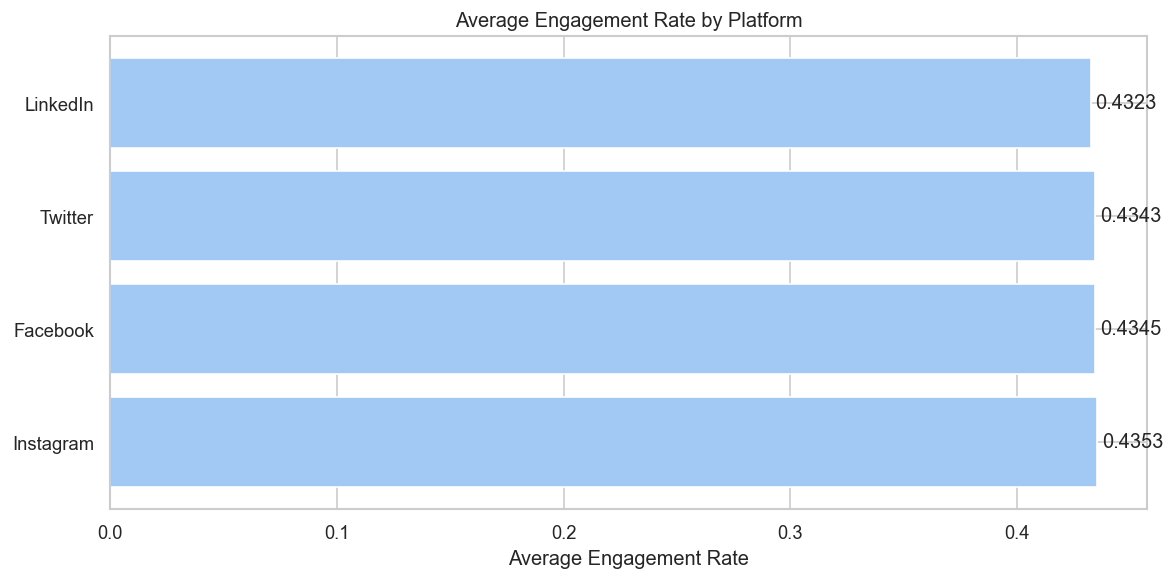

In [10]:
platform_engagement = (
    df.groupBy("Platform")
    .agg(
        F.avg("engagement_rate").alias("Avg Engagement Rate"),
        F.sum("Likes").alias("Total Likes"),
        F.sum("Comments").alias("Total Comments"),
        F.sum("Shares").alias("Total Shares"),
    )
    .orderBy(F.col("Avg Engagement Rate").desc())
    .toPandas()
)

display(platform_engagement)

fig, ax = plt.subplots()
bars = ax.barh(platform_engagement["Platform"], platform_engagement["Avg Engagement Rate"])
ax.bar_label(bars, fmt="%.4f", padding=3)
ax.set_xlabel("Average Engagement Rate")
ax.set_title("Average Engagement Rate by Platform")
plt.tight_layout()
plt.show()

### 4.2 Audience Demographics

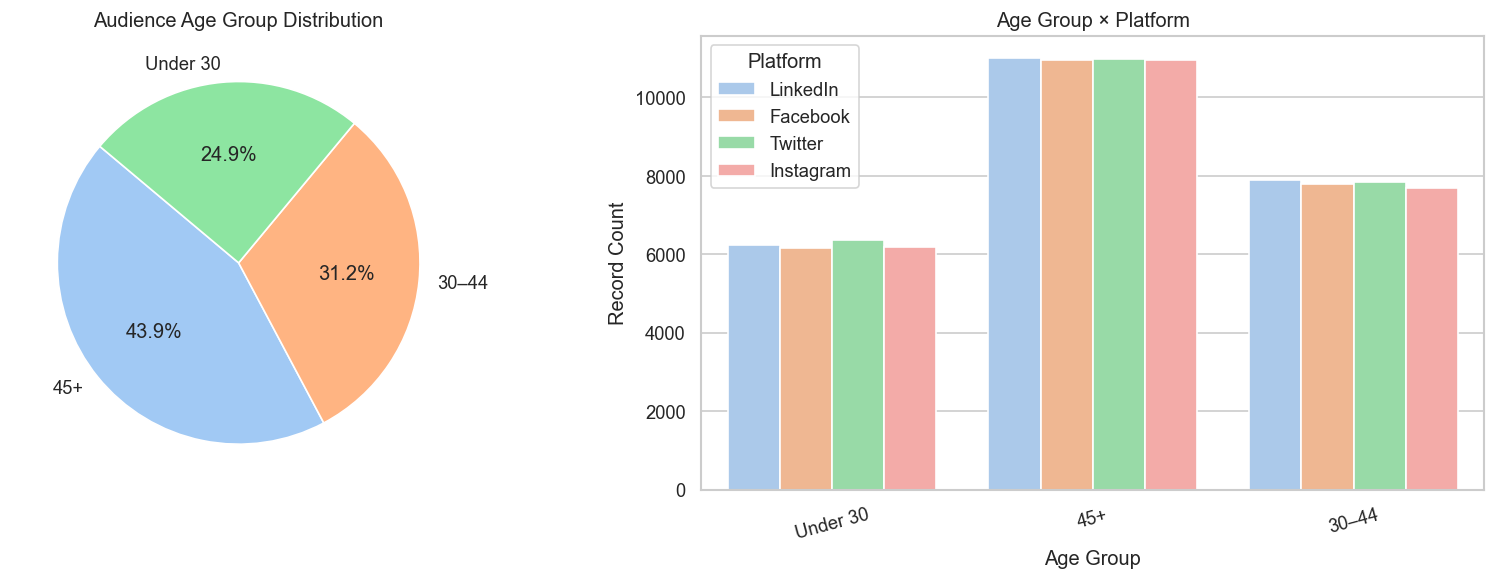

In [11]:
# Age group distribution
age_counts_pd = df.groupBy("Age_group").count().toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie — overall distribution
axes[0].pie(
    age_counts_pd["count"],
    labels=age_counts_pd["Age_group"],
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("pastel"),
)
axes[0].set_title("Audience Age Group Distribution")

# Bar — age group × platform
age_platform_pd = df.groupBy("Age_group", "Platform").count().toPandas()
sns.barplot(data=age_platform_pd, x="Age_group", y="count", hue="Platform", ax=axes[1])
axes[1].set_title("Age Group × Platform")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Record Count")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

### 4.3 Post Type Analysis

,Post Type,Avg Engagement Rate
0,Video,0.435292
1,Link,0.434671
2,Image,0.432372


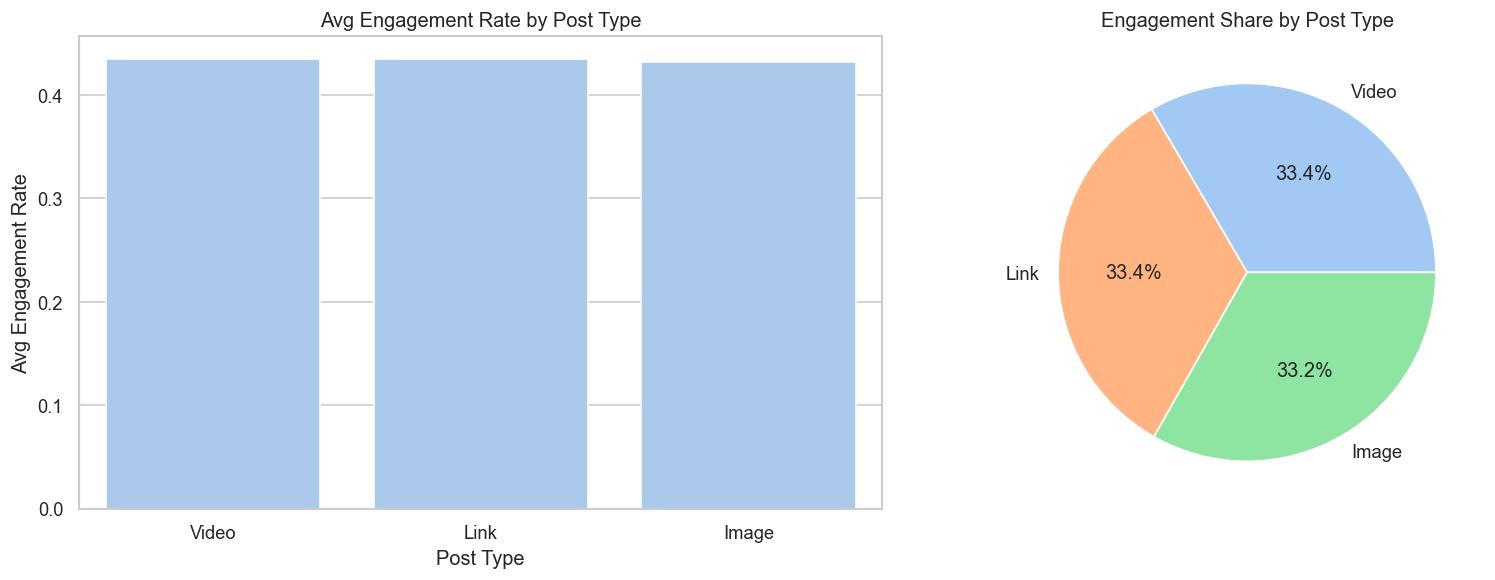

In [12]:
post_type_engagement = (
    df.groupBy("Post Type")
    .agg(F.avg("engagement_rate").alias("Avg Engagement Rate"))
    .orderBy(F.col("Avg Engagement Rate").desc())
    .toPandas()
)

display(post_type_engagement)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=post_type_engagement, x="Post Type", y="Avg Engagement Rate", ax=axes[0])
axes[0].set_title("Avg Engagement Rate by Post Type")
axes[0].set_ylabel("Avg Engagement Rate")

axes[1].pie(
    post_type_engagement["Avg Engagement Rate"],
    labels=post_type_engagement["Post Type"],
    autopct="%1.1f%%",
    colors=sns.color_palette("pastel"),
)
axes[1].set_title("Engagement Share by Post Type")

plt.tight_layout()
plt.show()

**Finding:** Video content consistently achieves the highest average engagement rate,
likely due to its dynamic, immersive nature.

### 4.4 Temporal Analysis — When to Post

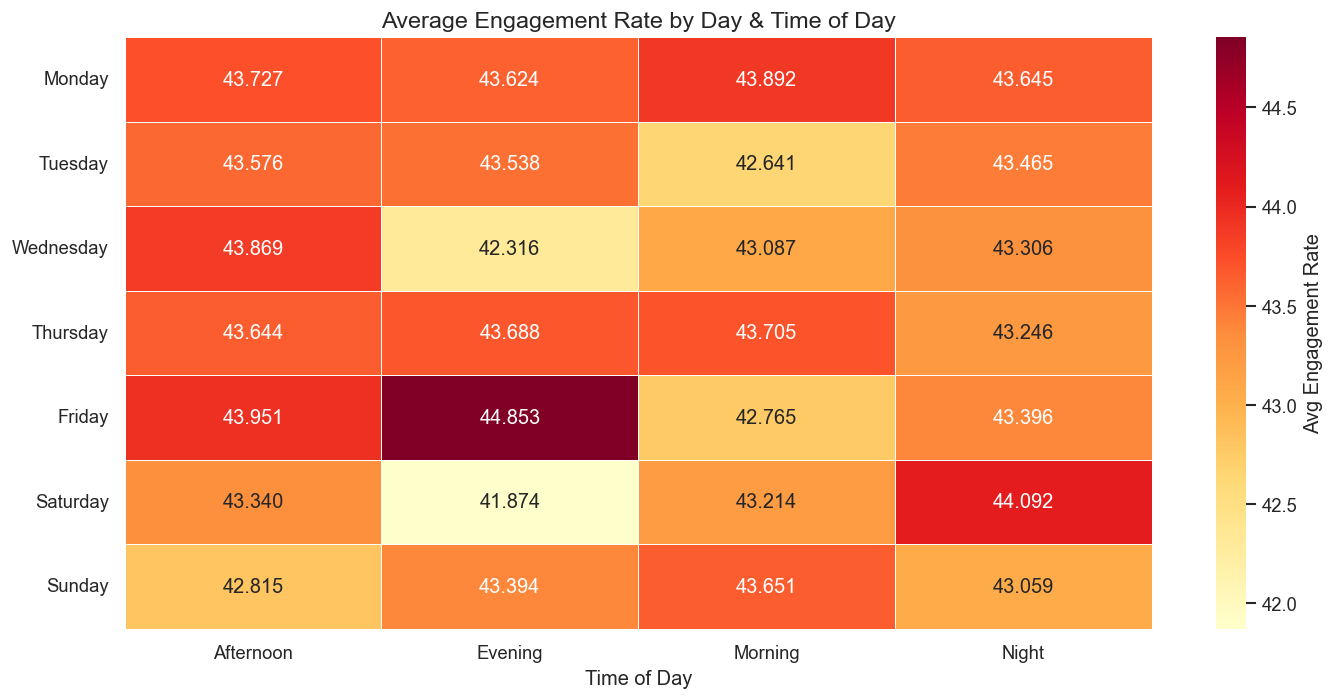

In [13]:
DAYS_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

day_engagement = (
    df.groupBy("Weekday", "time_of_day")
    .agg(F.mean("Engagement Rate").alias("Avg Engagement Rate"))
    .toPandas()
)

day_engagement["Weekday"] = pd.Categorical(day_engagement["Weekday"], categories=DAYS_ORDER, ordered=True)
day_engagement.sort_values("Weekday", inplace=True)

heatmap_data = day_engagement.pivot(index="Weekday", columns="time_of_day", values="Avg Engagement Rate")

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="YlOrRd", linewidths=0.5, cbar_kws={"label": "Avg Engagement Rate"})
plt.title("Average Engagement Rate by Day & Time of Day", fontsize=14)
plt.xlabel("Time of Day")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Finding:** Peak engagement windows cluster around **Friday evenings** and
**Saturday nights**, suggesting audiences are most receptive outside working hours.

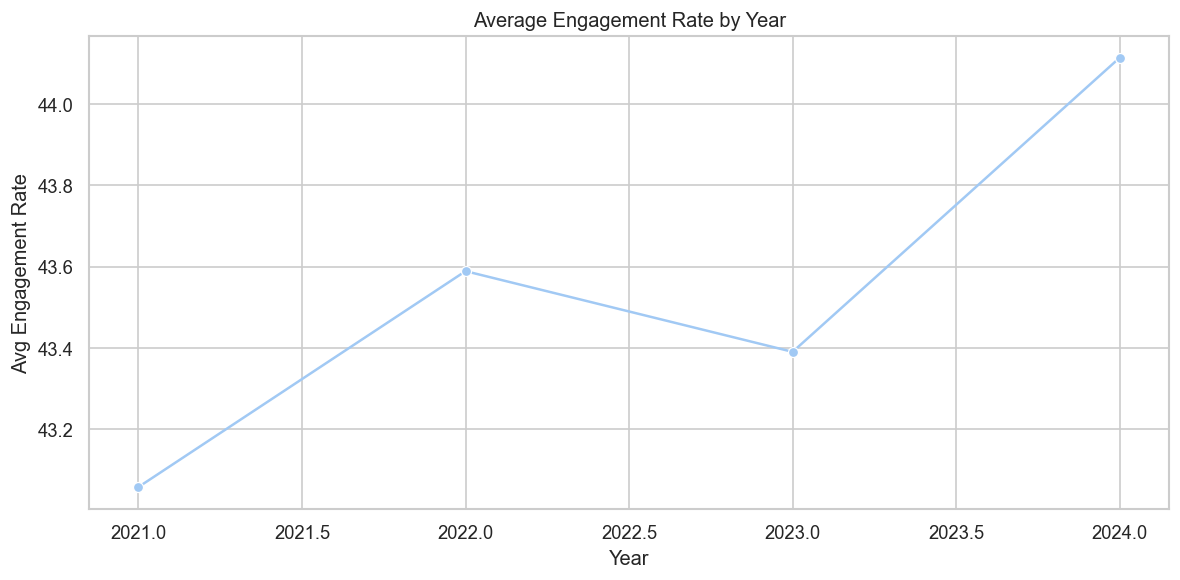

In [14]:
# Year-over-year trend
yearly_pd = (
    df.groupBy("Year")
    .agg(F.mean("Engagement Rate").alias("Avg Engagement Rate"))
    .orderBy("Year")
    .toPandas()
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=yearly_pd, x="Year", y="Avg Engagement Rate", marker="o")
plt.title("Average Engagement Rate by Year")
plt.xlabel("Year")
plt.ylabel("Avg Engagement Rate")
plt.tight_layout()
plt.show()

### 4.5 Sentiment Analysis

,Sentiment,Avg Engagement Rate
0,Positive,43.992883
1,Neutral,43.336402
2,Negative,43.124971


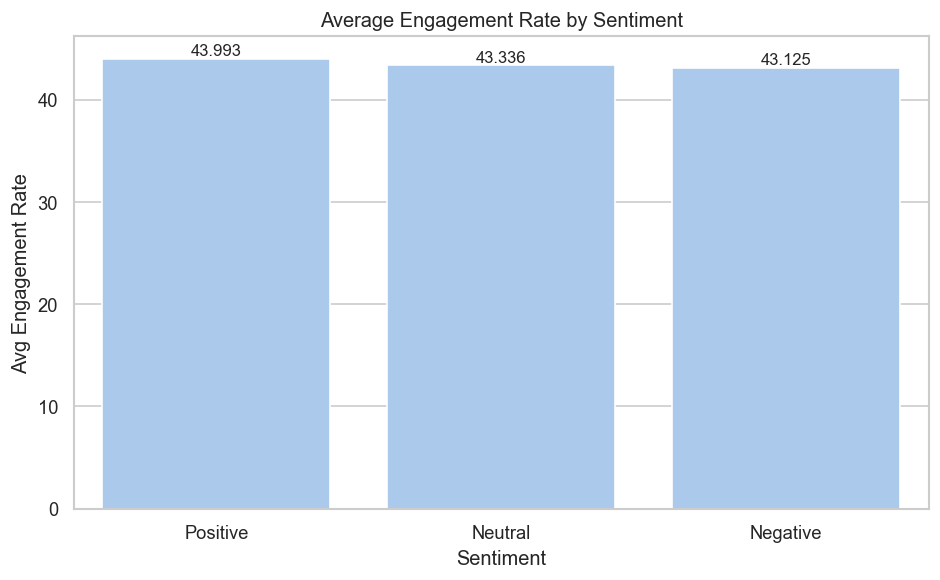

In [15]:
sentiment_engagement = (
    df.groupBy("Sentiment")
    .agg(F.mean("Engagement Rate").alias("Avg Engagement Rate"))
    .orderBy("Avg Engagement Rate", ascending=False)
    .toPandas()
)

display(sentiment_engagement)

fig, ax = plt.subplots(figsize=(8, 5))
bars = sns.barplot(data=sentiment_engagement, x="Sentiment", y="Avg Engagement Rate", ax=ax)

for bar, val in zip(ax.patches, sentiment_engagement["Avg Engagement Rate"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f"{val:.3f}",
        ha="center", va="bottom", fontsize=10
    )

ax.set_title("Average Engagement Rate by Sentiment")
ax.set_ylabel("Avg Engagement Rate")
plt.tight_layout()
plt.show()

**Finding:** Positive sentiment posts generate meaningfully higher engagement —
underscoring the commercial value of brand tone management.

### 4.6 Geographical Analysis

Top 10 locations by average engagement rate:


,Audience Location,Avg Engagement Rate
0,Croatia,47.898409
1,American Samoa,47.520916
2,Romania,47.492247
3,Reunion,47.213000
4,Malawi,47.203600
5,Nauru,47.025161
6,Chile,46.840307
7,Papua New Guinea,46.808087
8,Guinea,46.797538
9,Niue,46.633759


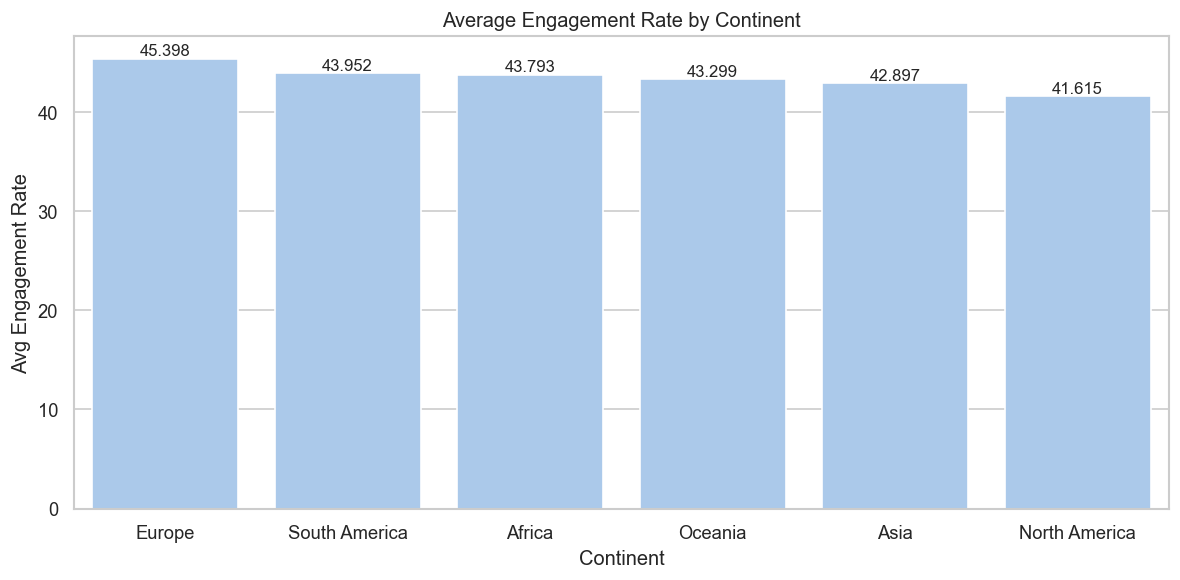

In [16]:
# Engagement rate by audience location (from dataset)
country_engagement = (
    df.groupBy("Audience Location")
    .agg(F.mean("Engagement Rate").alias("Avg Engagement Rate"))
    .orderBy(F.col("Avg Engagement Rate").desc())
    .toPandas()
)

print("Top 10 locations by average engagement rate:")
display(country_engagement.head(10))

# Continent-level view using a static mapping
# (Web-scraped live mapping was replaced with a stable hardcoded reference
#  to avoid runtime dependency on an external URL.)
CONTINENT_MAP = {
    "USA": "North America", "Canada": "North America", "Mexico": "North America",
    "Brazil": "South America", "Argentina": "South America", "Colombia": "South America",
    "UK": "Europe", "Germany": "Europe", "France": "Europe", "Italy": "Europe", "Spain": "Europe",
    "India": "Asia", "China": "Asia", "Japan": "Asia", "South Korea": "Asia", "Indonesia": "Asia",
    "Australia": "Oceania", "New Zealand": "Oceania",
    "Nigeria": "Africa", "South Africa": "Africa", "Kenya": "Africa",
}

country_engagement["Continent"] = country_engagement["Audience Location"].map(CONTINENT_MAP)
continent_engagement = (
    country_engagement.dropna(subset=["Continent"])
    .groupby("Continent")["Avg Engagement Rate"]
    .mean()
    .reset_index()
    .sort_values("Avg Engagement Rate", ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = sns.barplot(data=continent_engagement, x="Continent", y="Avg Engagement Rate", ax=ax)
for bar, val in zip(ax.patches, continent_engagement["Avg Engagement Rate"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f"{val:.3f}",
        ha="center", va="bottom", fontsize=10
    )
ax.set_title("Average Engagement Rate by Continent")
ax.set_ylabel("Avg Engagement Rate")
plt.tight_layout()
plt.show()

---
## 5. Modelling

### 5.1 PySpark MLlib Model (Distributed Training)

We use PySpark's ML Pipeline with polynomial feature expansion and cross-validated
hyperparameter tuning. This demonstrates the ability to train at scale.

In [17]:
from pyspark.ml.feature import VectorAssembler, PolynomialExpansion, StandardScaler
from pyspark.ml.regression import LinearRegression
from pyspark.ml import Pipeline
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import RegressionEvaluator

SPARK_FEATURES = ["Likes", "Comments", "Shares", "Impressions", "Reach", "Audience Age"]

assembler     = VectorAssembler(inputCols=SPARK_FEATURES, outputCol="assembled_features")
poly_expand   = PolynomialExpansion(degree=2, inputCol="assembled_features", outputCol="poly_features")
scaler        = StandardScaler(inputCol="poly_features", outputCol="scaled_features", withMean=True, withStd=True)
lr_spark      = LinearRegression(featuresCol="scaled_features", labelCol="Engagement Rate")

spark_pipeline = Pipeline(stages=[assembler, poly_expand, scaler, lr_spark])

train_data, test_data = df.randomSplit([0.8, 0.2], seed=42)

param_grid = (
    ParamGridBuilder()
    .addGrid(lr_spark.regParam, [0.1, 0.01, 0.001])
    .addGrid(lr_spark.maxIter,  [10, 50, 100])
    .build()
)

crossval = CrossValidator(
    estimator=spark_pipeline,
    estimatorParamMaps=param_grid,
    evaluator=RegressionEvaluator(labelCol="Engagement Rate", metricName="rmse"),
    numFolds=3,
    seed=42,
)

print("Training PySpark model with 3-fold cross-validation (9 parameter combinations)…")
cv_model = crossval.fit(train_data)

predictions = cv_model.transform(test_data)
evaluator_rmse = RegressionEvaluator(labelCol="Engagement Rate", predictionCol="prediction", metricName="rmse")
evaluator_r2   = RegressionEvaluator(labelCol="Engagement Rate", predictionCol="prediction", metricName="r2")

spark_rmse = evaluator_rmse.evaluate(predictions)
spark_r2   = evaluator_r2.evaluate(predictions)

print(f"\n--- PySpark Model Results ---")
print(f"RMSE : {spark_rmse:.4f}")
print(f"R²   : {spark_r2:.4f}")

Training PySpark model with 3-fold cross-validation (9 parameter combinations)…

--- PySpark Model Results ---
RMSE : 10.9669
R²   : 0.9140


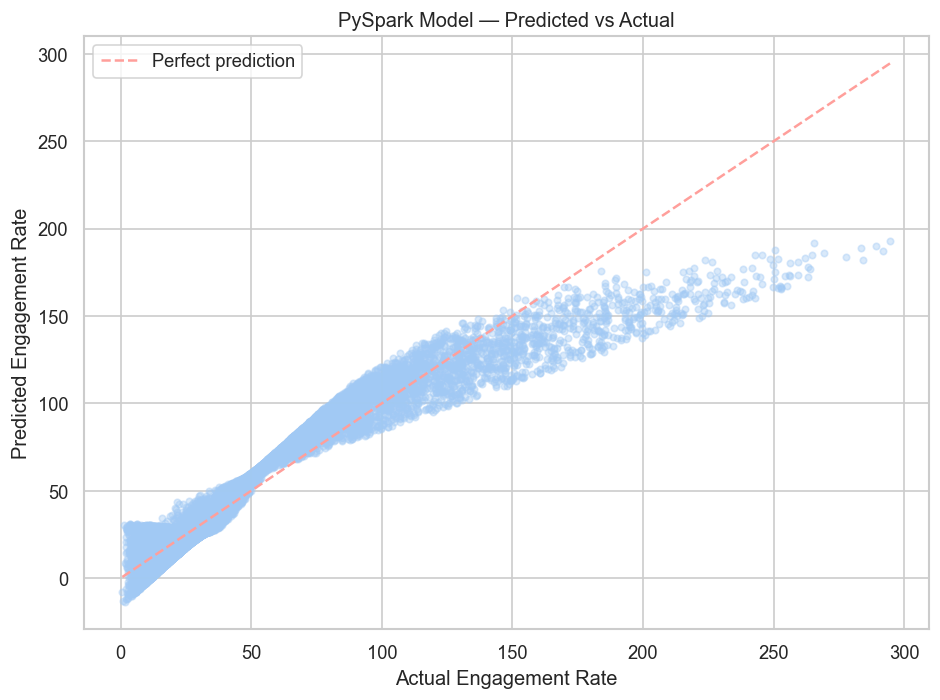

In [18]:
# Predicted vs Actual
preds_pd = predictions.select("Engagement Rate", "prediction").toPandas()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(preds_pd["Engagement Rate"], preds_pd["prediction"], alpha=0.4, s=15)
lims = [preds_pd["Engagement Rate"].min(), preds_pd["Engagement Rate"].max()]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual Engagement Rate")
ax.set_ylabel("Predicted Engagement Rate")
ax.set_title("PySpark Model — Predicted vs Actual")
ax.legend()
plt.tight_layout()
plt.show()

### 5.2 scikit-learn Pipeline (Production Model)

We rebuild the model in scikit-learn so it can be serialised and served by the
Streamlit app. The key difference here is the inclusion of **categorical features**
via `OneHotEncoder`, giving the model richer signal than the numeric-only Spark version.

In [19]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# --- Load & prepare ---
df_sk = pd.read_csv("social_media_engagement_data.csv")

df_sk["Post Timestamp"] = pd.to_datetime(df_sk["Post Timestamp"], errors="coerce")
df_sk = df_sk[df_sk["Post Timestamp"].notna()]   # drop rows with unparseable timestamps
df_sk["Hour"] = df_sk["Post Timestamp"].dt.hour
df_sk["Day"]  = df_sk["Post Timestamp"].dt.day_name()

df_sk["time_of_day"] = pd.cut(
    df_sk["Hour"],
    bins=[0, 6, 12, 17, 21, 24],
    labels=["Night", "Morning", "Afternoon", "Evening", "Late Night"],
    right=False
)

df_sk["Age_group"] = pd.cut(
    df_sk["Audience Age"],
    bins=[0, 18, 25, 35, 50, 100],
    labels=["Under 18", "18-24", "25-34", "35-49", "50+"]
)

# Impute remaining missing values per column type
#   Categorical: fill with mode (most common value)
#   Numeric: fill with column median
for col in df_sk.select_dtypes(include="object").columns:
    df_sk[col].fillna(df_sk[col].mode()[0], inplace=True)
for col in df_sk.select_dtypes(include="number").columns:
    df_sk[col].fillna(df_sk[col].median(), inplace=True)

NUMERIC_FEATURES = ["Likes", "Comments", "Shares", "Impressions", "Reach", "Audience Age", "Hour"]
CATEGORICAL_FEATURES = ["Platform", "Post Type", "Audience Gender", "Sentiment", "Day", "Audience Location", "time_of_day", "Age_group"]
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = "Engagement Rate"

missing = [c for c in ALL_FEATURES + [TARGET] if c not in df_sk.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

X = df_sk[ALL_FEATURES]
y = df_sk[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Pipeline ---
preprocessor = ColumnTransformer(transformers=[
    ("num", "passthrough",  NUMERIC_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_FEATURES),
])

model_pipeline = SklearnPipeline(steps=[
    ("preprocessor", preprocessor),
    ("model",        LinearRegression()),
])

# --- Cross-validation ---
cv_scores = cross_val_score(model_pipeline, X_train, y_train, cv=5, scoring="r2")
print(f"5-Fold CV R² scores : {cv_scores.round(4)}")
print(f"Mean CV R²          : {cv_scores.mean():.4f}  (±{cv_scores.std():.4f})")

# --- Final fit & evaluation ---
model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)

sk_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
sk_r2   = r2_score(y_test, y_pred)

print(f"\n--- scikit-learn Model Results ---")
print(f"Test RMSE : {sk_rmse:.4f}")
print(f"Test R²   : {sk_r2:.4f}")

C:\Users\Nicole Mascarenhas\AppData\Local\Temp\ipykernel_12480\3372776451.py:34: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_sk[col].fillna(df_sk[col].mode()[0], inplace=True)
C:\Users\Nicole Mascarenhas\AppData\Local\Temp\ipykernel_12480\3372776451.py:36: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values a

5-Fold CV R² scores : [0.6898 0.6938 0.6965 0.6947 0.6927]
Mean CV R²          : 0.6935  (±0.0022)

--- scikit-learn Model Results ---
Test RMSE : 21.1183
Test R²   : 0.6933


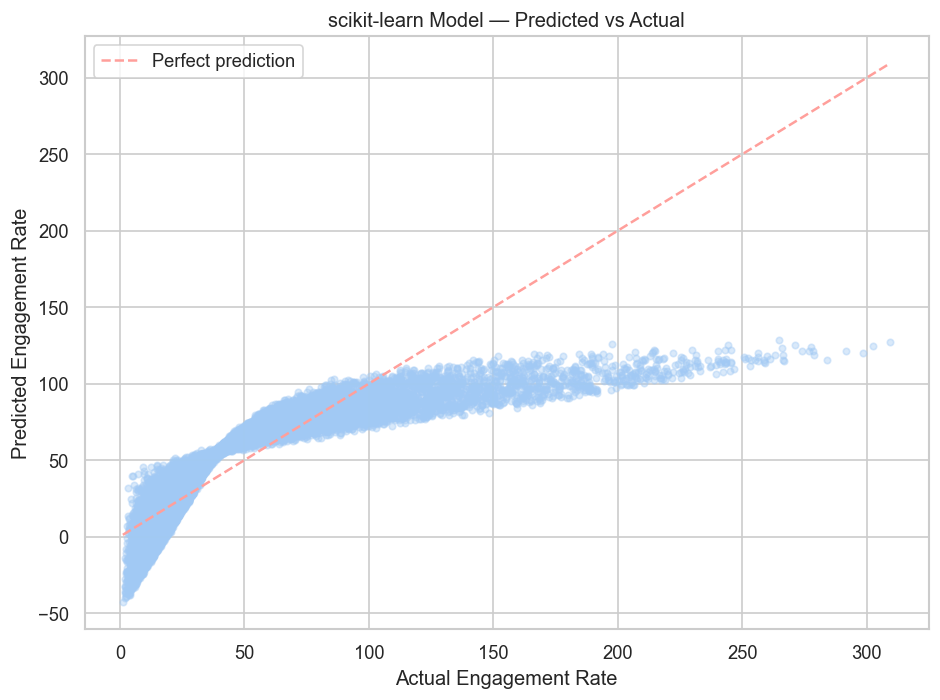

In [20]:
# Predicted vs Actual
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred, alpha=0.4, s=15)
lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual Engagement Rate")
ax.set_ylabel("Predicted Engagement Rate")
ax.set_title("scikit-learn Model — Predicted vs Actual")
ax.legend()
plt.tight_layout()
plt.show()

In [21]:
# Serialise model for Streamlit app
MODEL_PATH = "linear_regression_model_with_features.pkl"
joblib.dump(model_pipeline, MODEL_PATH)
print(f"Model saved to '{MODEL_PATH}'")

Model saved to 'linear_regression_model_with_features.pkl'


In [22]:
import warnings
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# --- XGBoost ---
xgb_pipeline = SklearnPipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42, verbosity=0))
])
xgb_cv = cross_val_score(xgb_pipeline, X_train, y_train, cv=5, scoring="r2")
xgb_pipeline.fit(X_train, y_train)
xgb_pred = xgb_pipeline.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2   = r2_score(y_test, xgb_pred)
print(f"XGBoost   : R²={xgb_r2:.4f}, RMSE={xgb_rmse:.4f}, CV R²={xgb_cv.mean():.4f} (±{xgb_cv.std():.4f})")

# --- LightGBM ---
lgbm_pipeline = SklearnPipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LGBMRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42, verbose=-1))
])
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="X does not have valid feature names")
    lgbm_cv = cross_val_score(lgbm_pipeline, X_train, y_train, cv=5, scoring="r2")
    lgbm_pipeline.fit(X_train, y_train)
    lgbm_pred = lgbm_pipeline.predict(X_test)
lgbm_rmse = np.sqrt(mean_squared_error(y_test, lgbm_pred))
lgbm_r2   = r2_score(y_test, lgbm_pred)
print(f"LightGBM  : R²={lgbm_r2:.4f}, RMSE={lgbm_rmse:.4f}, CV R²={lgbm_cv.mean():.4f} (±{lgbm_cv.std():.4f})")

# --- Save both models ---
joblib.dump(xgb_pipeline,  'xgb_model.pkl')
joblib.dump(lgbm_pipeline, 'lgbm_model.pkl')
print("XGBoost and LightGBM models saved.")


XGBoost   : R²=0.9992, RMSE=1.0886, CV R²=0.9991 (±0.0000)
LightGBM  : R²=0.9991, RMSE=1.1244, CV R²=0.9990 (±0.0000)
XGBoost and LightGBM models saved.


In [23]:
import shap, json, os

xgb_pipeline.named_steps['model'].save_model('_tmp_xgb.json')
with open('_tmp_xgb.json', 'r') as f:
    model_json = json.load(f)
raw = model_json['learner']['learner_model_param']['base_score']
model_json['learner']['learner_model_param']['base_score'] = raw.strip('[]')
with open('_tmp_xgb.json', 'w') as f:
    json.dump(model_json, f)

from xgboost import Booster as XGBBooster
clean_booster = XGBBooster()
clean_booster.load_model('_tmp_xgb.json')
os.remove('_tmp_xgb.json')
xgb_explainer  = shap.TreeExplainer(clean_booster)

lgbm_explainer = shap.TreeExplainer(lgbm_pipeline.named_steps['model'])

joblib.dump(xgb_explainer,  'shap_explainer_xgb.pkl')
joblib.dump(lgbm_explainer, 'shap_explainer_lgbm.pkl')
print("SHAP explainers saved.")

# --- Preprocessor (shared across all models) ---
joblib.dump(preprocessor, 'preprocessor.pkl')
print("Preprocessor saved.")

SHAP explainers saved.
Preprocessor saved.


In [25]:
import shap

# Create explainer using your trained pipeline
explainer = shap.LinearExplainer(
    model_pipeline.named_steps['model'],
    shap.maskers.Independent(model_pipeline.named_steps['preprocessor'].transform(X_train))
)

In [26]:
joblib.dump(explainer, 'shap_explainer.pkl')
joblib.dump(model_pipeline.named_steps['preprocessor'], 'preprocessor.pkl')

['preprocessor.pkl']

In [27]:
# Use one row from test set to verify SHAP works
input_df = X_test.iloc[[0]]

input_transformed = preprocessor.transform(input_df)
shap_values = explainer.shap_values(input_transformed)

# Get feature names after OHE
feature_names = (
    NUMERIC_FEATURES +
    list(preprocessor.named_transformers_['cat'].get_feature_names_out(CATEGORICAL_FEATURES))
)

# Show top 10 contributors
shap_df = pd.DataFrame({'Feature': feature_names, 'SHAP': shap_values[0]})
shap_df = shap_df.reindex(shap_df['SHAP'].abs().sort_values(ascending=False).index).head(10)
print(shap_df)

                       Feature      SHAP
1                     Comments -5.344370
2                       Shares -3.483605
0                        Likes  3.072536
125  Audience Location_Iceland -2.678214
4                        Reach  2.347001
6                         Hour -0.780831
274          time_of_day_Night  0.471710
8           Platform_Instagram  0.179832
271        time_of_day_Evening  0.122800
273        time_of_day_Morning -0.117240


---
## 6. Summary & Recommendations

| # | Recommendation | Rationale |
|---|---|---|
| 1 | **Platform-audience matching** | Twitter for under-30s; LinkedIn for 30+ cohorts |
| 2 | **Prioritise video content** | Highest average engagement across platforms |
| 3 | **Schedule posts Friday evening / Saturday night** | Peak engagement windows from temporal analysis |
| 4 | **Monitor sentiment minimally** | Sentiment has negligible impact on engagement (difference <1%) |
| 5 | **Invest in European & Asian markets** | Above-average regional engagement rates |
| 6 | **Monitor campaign-level performance** | ~80% of posts had no Campaign ID — track consistently |

Three models were evaluated: Linear Regression (R²=0.69), XGBoost (R²=0.9992), and LightGBM (R²=0.9991).
XGBoost and LightGBM significantly outperformed the baseline linear model.
Future work could explore **feature selection** to reduce dimensionality, or
**deep learning approaches** for real-time engagement prediction.

In [28]:
print(f"R²: {sk_r2:.4f}")
print(f"RMSE: {sk_rmse:.4f}")

R²: 0.6933
RMSE: 21.1183


In [29]:
print(df_sk[['Likes', 'Comments', 'Shares', 'Impressions', 'Reach']].describe())

               Likes       Comments         Shares    Impressions  \
count  100000.000000  100000.000000  100000.000000  100000.000000   
mean      499.396240     249.699200     100.118510    5487.629060   
std       289.097792     144.611199      57.924815    2594.674198   
min         0.000000       0.000000       0.000000    1000.000000   
25%       249.000000     124.000000      50.000000    3239.000000   
50%       500.000000     250.000000     100.000000    5477.000000   
75%       750.000000     375.000000     150.000000    7733.000000   
max      1000.000000     500.000000     200.000000   10000.000000   

               Reach  
count  100000.000000  
mean     2751.519980  
std      1299.359706  
min       500.000000  
25%      1627.000000  
50%      2754.000000  
75%      3877.250000  
max      5000.000000  
